In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from project_utils import (C_elastic, yield_surface_MC, crosspoint,
                            fnormal_MC, gnormal_MC, f_constraint,
                            Bardet_triaxial, MC_forward, plot_MC)

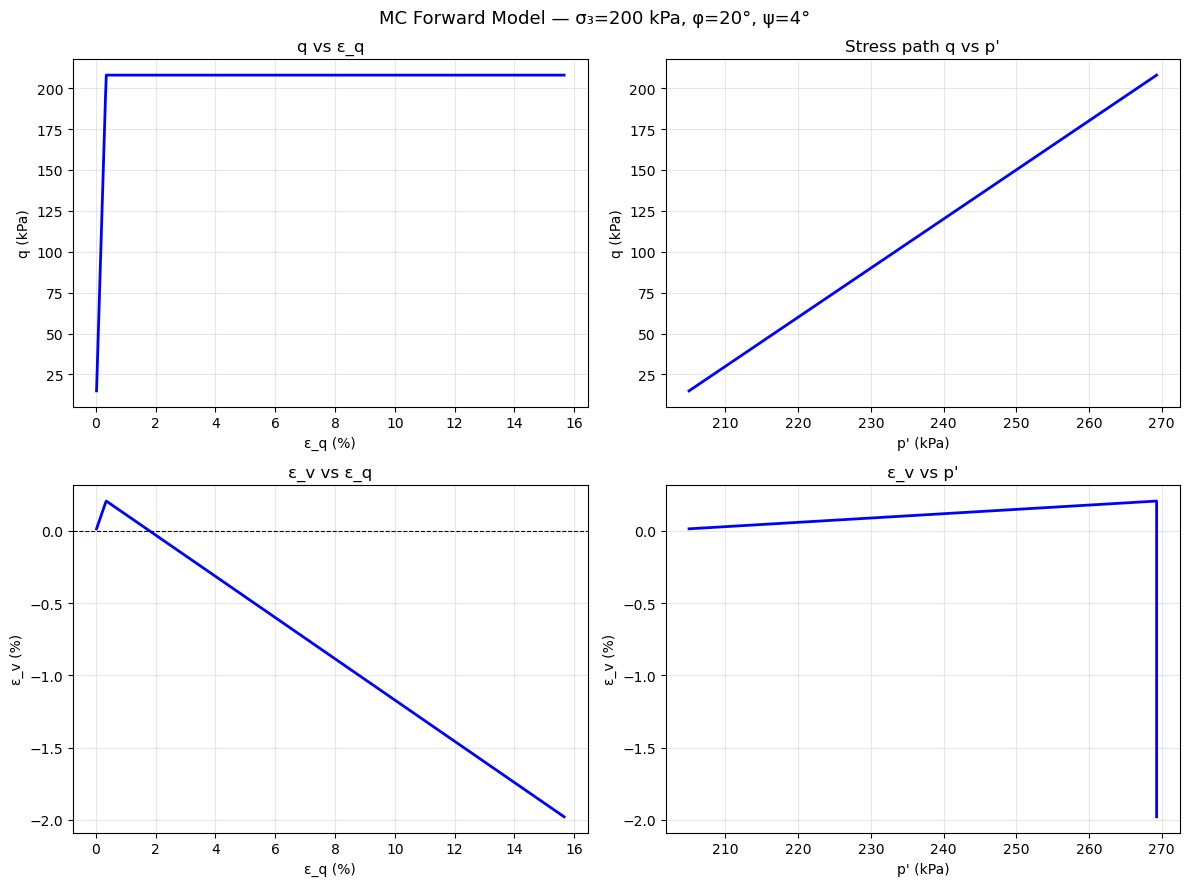

In [ ]:
# forward model test run
    E  = 50000 #kPa
    nu = 0.25
    K  = E / (3*(1 - 2*nu))
    G  = E / (2*(1 + nu))
    phi_deg = 20.0
    psi_deg = 4.0
    c       = 0.0
    sigma3  = 200.0
    
    q, eps_q, eps_v, p = MC_forward(
        K,
        G,
        phi_deg,
        psi_deg,
        c,
        sigma3,
        eps_max = 0.15,
        n_steps = 500,
        load_tag = 110
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0,0].plot(eps_q*100, q, 'b', lw=2)
    axes[0,0].set_xlabel('ε_q (%)') 
    axes[0,0].set_ylabel('q (kPa)')
    axes[0,0].set_title('q vs ε_q') 
    axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(p, q, 'b', lw=2)
    axes[0,1].set_xlabel("p' (kPa)")
    axes[0,1].set_ylabel('q (kPa)')
    axes[0,1].set_title("Stress path q vs p'")
    axes[0,1].grid(alpha=0.3)

    axes[1,0].plot(eps_q*100, eps_v*100, 'b', lw=2)
    axes[1,0].set_xlabel('ε_q (%)')
    axes[1,0].set_ylabel('ε_v (%)')
    axes[1,0].set_title('ε_v vs ε_q')
    axes[1,0].grid(alpha=0.3)
    axes[1,0].axhline(0, color='k', lw=0.8, ls='--')

    axes[1,1].plot(p, eps_v*100, 'b', lw=2)
    axes[1,1].set_xlabel("p' (kPa)")
    axes[1,1].set_ylabel('ε_v (%)')
    axes[1,1].set_title("ε_v vs p'")
    axes[1,1].grid(alpha=0.3)

    plt.suptitle(f'MC Forward Model — σ₃={sigma3:.0f} kPa, φ={phi_deg:.0f}°, ψ={psi_deg:.0f}°', fontsize=13)
    plt.tight_layout()
    plt.show()

## Inversion

In [ ]:
# initial guess
E_0 = 50000 #kPa    
nu = 0.25
K_0  = E / (3*(1 - 2*nu))
G_0  = E / (2*(1 + nu))
phi_deg = 20.0
psi_deg = 4.0

m = [K_0, G_0, phi_deg, psi_deg]
